# Create snow pillow comparison dataset

Mirrors `../compare_to_NorSWE/1_create_NorSWE_comparison_dataset.ipynb`, using the combined public snow station archive built in `0_download_and_preprocess_all_snow_pillow_data.ipynb`.

Steps:
1. Open the snow pillow Zarr, add water year / DOWY coordinates, restrict to WY 2015–2024 (full overlap with the SAR dataset)
2. Select stations: de-duplicate AWDB "MSNT" copies of native CCSS/BC stations, drop stations without SWE
3. QC the daily SWE series (spike removal, data-density and gap checks, seasonal-snowpack check)
4. Compute per-water-year max SWE value and %-of-max SWE timings → `data/comparison_datasets/max_snow_pillow_swe_timing.zarr`
5. Extract a 25×25 pixel chip (80 m pixels, ±1 km) from the global SAR runoff onset Zarr around each usable station → `data/comparison_datasets/runoff_onset_snow_pillow_station_chips.zarr`

In [1]:
import xarray as xr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import easysnowdata
import numpy as np
import rasterio
import os
import contextily as ctx
import shutil


DATA_DIR = Path("data/snow_pillows")
SNOW_PILLOW_ZARR_FILEPATH = DATA_DIR / "snow_pillows.zarr"

MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH = Path('data/comparison_datasets/max_snow_pillow_swe_timing.zarr')
RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH = Path('data/comparison_datasets/runoff_onset_snow_pillow_station_chips.zarr')

# --- temporal overlap of SAR dataset (WY 2015-2024) and the ongoing snow pillow archives ---
TARGET_WATER_YEARS = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

In [2]:
snow_pillows_ds = xr.open_zarr(SNOW_PILLOW_ZARR_FILEPATH)
snow_pillows_ds

<xarray.Dataset> Size: 577MB
Dimensions:       (time: 47333, station_id: 1522)
Coordinates:
  * time          (time) datetime64[ns] 379kB 1896-12-01 ... 2026-07-05
  * station_id    (station_id) <U16 97kB '0280_AK_COOP' ... 'WWC_CA_MSNT'
    client        (station_id) <U6 37kB dask.array<chunksize=(1522,), meta=np.ndarray>
    elevation     (station_id) float32 6kB dask.array<chunksize=(1522,), meta=np.ndarray>
    latitude      (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    longitude     (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    network       (station_id) <U5 30kB dask.array<chunksize=(1522,), meta=np.ndarray>
    state         (station_id) <U2 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    station_name  (station_id) <U36 219kB dask.array<chunksize=(1522,), meta=np.ndarray>
Data variables:
    snow_depth    (time, station_id) float32 288MB dask.array<chunksize=(4000, 1522), meta=np.ndarray>
    swe           (time, station_id) float32 288MB dask.array<chunksize=(4000, 1522), meta=np.ndarray>
Attributes:
    source_url:   https://github.com/egagli/global_snow_networks
    description:  Daily SWE and snow depth from public snow networks (SNOTEL,...

In [3]:
snow_pillows_ds.coords['water_year'] = ("time", pd.to_datetime(snow_pillows_ds['time']).map(easysnowdata.utils.datetime_to_WY))
snow_pillows_ds.coords['DOWY'] = ("time", pd.to_datetime(snow_pillows_ds['time']).map(easysnowdata.utils.datetime_to_DOWY))
snow_pillows_ds

<xarray.Dataset> Size: 578MB
Dimensions:       (time: 47333, station_id: 1522)
Coordinates:
  * time          (time) datetime64[ns] 379kB 1896-12-01 ... 2026-07-05
    water_year    (time) int64 379kB 1897 1897 1897 1897 ... 2026 2026 2026 2026
    DOWY          (time) int64 379kB 62 63 64 65 66 67 ... 274 275 276 277 278
  * station_id    (station_id) <U16 97kB '0280_AK_COOP' ... 'WWC_CA_MSNT'
    client        (station_id) <U6 37kB dask.array<chunksize=(1522,), meta=np.ndarray>
    elevation     (station_id) float32 6kB dask.array<chunksize=(1522,), meta=np.ndarray>
    latitude      (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    longitude     (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    network       (station_id) <U5 30kB dask.array<chunksize=(1522,), meta=np.ndarray>
    state         (station_id) <U2 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    station_name  (station_id) <U36 219kB dask.array<chunksize=(1522,), meta=np.ndarray>
Data variables:
    snow_depth    (time, station_id) float32 288MB dask.array<chunksize=(4000, 1522), meta=np.ndarray>
    swe           (time, station_id) float32 288MB dask.array<chunksize=(4000, 1522), meta=np.ndarray>
Attributes:
    source_url:   https://github.com/egagli/global_snow_networks
    description:  Daily SWE and snow depth from public snow networks (SNOTEL,...

In [4]:
snow_pillows_ds = snow_pillows_ds.sel(time=snow_pillows_ds['water_year'].isin(TARGET_WATER_YEARS))
snow_pillows_ds

<xarray.Dataset> Size: 45MB
Dimensions:       (time: 3653, station_id: 1522)
Coordinates:
  * time          (time) datetime64[ns] 29kB 2014-10-01 ... 2024-09-30
    water_year    (time) int64 29kB 2015 2015 2015 2015 ... 2024 2024 2024 2024
    DOWY          (time) int64 29kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * station_id    (station_id) <U16 97kB '0280_AK_COOP' ... 'WWC_CA_MSNT'
    client        (station_id) <U6 37kB dask.array<chunksize=(1522,), meta=np.ndarray>
    elevation     (station_id) float32 6kB dask.array<chunksize=(1522,), meta=np.ndarray>
    latitude      (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    longitude     (station_id) float64 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    network       (station_id) <U5 30kB dask.array<chunksize=(1522,), meta=np.ndarray>
    state         (station_id) <U2 12kB dask.array<chunksize=(1522,), meta=np.ndarray>
    station_name  (station_id) <U36 219kB dask.array<chunksize=(1522,), meta=np.ndarray>
Data variables:
    snow_depth    (time, station_id) float32 22MB dask.array<chunksize=(3653, 1522), meta=np.ndarray>
    swe           (time, station_id) float32 22MB dask.array<chunksize=(3653, 1522), meta=np.ndarray>
Attributes:
    source_url:   https://github.com/egagli/global_snow_networks
    description:  Daily SWE and snow depth from public snow networks (SNOTEL,...

## Station selection

The same physical station can appear twice in the archive: AWDB re-serves some CCSS and BC Snow Survey stations under its "MSNT" network label. Prefer the native clients (`cdec`, `databc`) — their archives are longer — and drop MSNT entries within 200 m of a native CCSS/BCSS station. Then drop stations with no SWE observations in the target water years (snow-depth-only sites etc.).

In [5]:
snow_pillow_gdf = gpd.GeoDataFrame(
    {
        'station_id':   snow_pillows_ds['station_id'].values,
        'station_name': snow_pillows_ds['station_name'].values,
        'network':      snow_pillows_ds['network'].values,
        'client':       snow_pillows_ds['client'].values,
        'state':        snow_pillows_ds['state'].values,
        'elevation':    snow_pillows_ds['elevation'].values,
    },
    geometry=gpd.points_from_xy(snow_pillows_ds['longitude'].values, snow_pillows_ds['latitude'].values),
    crs='EPSG:4326',
)

msnt_gdf   = snow_pillow_gdf[snow_pillow_gdf['network'] == 'MSNT'].to_crs(epsg=3857)
native_gdf = snow_pillow_gdf[snow_pillow_gdf['network'].isin(['CCSS', 'BCSS'])].to_crs(epsg=3857)

joined = gpd.sjoin_nearest(msnt_gdf, native_gdf, distance_col='dist_m', lsuffix='left', rsuffix='right')
duplicate_msnt_ids = joined.loc[joined['dist_m'] < 200, 'station_id_left'].unique()
print(f"Dropping {len(duplicate_msnt_ids)} MSNT stations that duplicate native CCSS/BCSS stations")

snow_pillows_ds = snow_pillows_ds.sel(station_id=~snow_pillows_ds['station_id'].isin(duplicate_msnt_ids))
snow_pillow_gdf = snow_pillow_gdf[~snow_pillow_gdf['station_id'].isin(duplicate_msnt_ids)].reset_index(drop=True)

Dropping 46 MSNT stations that duplicate native CCSS/BCSS stations


In [6]:
swe_da = snow_pillows_ds['swe'].load()

has_swe = swe_da.notnull().any(dim='time')
print(f"{int(has_swe.sum())}/{has_swe.sizes['station_id']} stations have SWE data in WY {TARGET_WATER_YEARS[0]}-{TARGET_WATER_YEARS[-1]}")
swe_da = swe_da.sel(station_id=has_swe)
swe_da

1265/1476 stations have SWE data in WY 2015-2024


<xarray.DataArray 'swe' (time: 3653, station_id: 1265)> Size: 18MB
array([[  nan,   nan,   nan, ...,   nan,  0.  ,  0.  ],
       [  nan,   nan,   nan, ...,   nan,  0.  ,  0.  ],
       [  nan,   nan,   nan, ...,   nan,  0.  ,  0.  ],
       ...,
       [12.7 ,   nan,  2.54, ...,  0.  ,  0.  ,  0.  ],
       [17.78,  0.  ,  2.54, ...,  0.  ,  0.  ,  0.  ],
       [17.78,   nan,  2.54, ...,  0.  ,  0.  ,  0.  ]],
      shape=(3653, 1265), dtype=float32)
Coordinates:
  * time          (time) datetime64[ns] 29kB 2014-10-01 ... 2024-09-30
    water_year    (time) int64 29kB 2015 2015 2015 2015 ... 2024 2024 2024 2024
    DOWY          (time) int64 29kB 1 2 3 4 5 6 7 ... 361 362 363 364 365 366
  * station_id    (station_id) <U16 81kB '05AA809_AB_MSNT' ... 'WWC_CA_MSNT'
    client        (station_id) <U6 30kB 'awdb' 'awdb' 'awdb' ... 'cdec' 'awdb'
    elevation     (station_id) float32 5kB 1.97e+03 1.92e+03 ... 2.774e+03
    latitude      (station_id) float64 10kB 49.36 49.78 51.08 ... 37.03 37.03
    longitude     (station_id) float64 10kB -114.5 -114.6 ... -118.9 -118.9
    network       (station_id) <U5 25kB 'MSNT' 'MSNT' 'MSNT' ... 'CCSS' 'MSNT'
    state         (station_id) <U2 10kB 'AB' 'AB' 'AB' 'AB' ... 'CA' 'CA' 'CA'
    station_name  (station_id) <U36 182kB 'Gardiner Creek' ... 'West Woodchuc...
Attributes:
    units:      mm
    long_name:  snow water equivalent

## Quality control

Daily pillow SWE series contain spikes, dropouts, and partial seasons. All thresholds are in mm of SWE:

1. Remove negative values
2. **Spike filter** — mask points where either adjacent day-to-day change is ≥ 200 mm (also masks points next to missing data)
3. **Data density** — require ≥ 10 valid observations in every centered 20-day window
4. **Per station-year checks** — NaN out a station's whole water year if it has > 30 missing days in Nov–Mar, any gap > 10 days between valid observations, or doesn't start *and* end (essentially) snow-free (first/last valid value ≤ 100 mm)
5. **Seasonal-snowpack check** — keep only station-years with SWE ≥ 100 mm for ≥ 55 days within some 60-day window

In [7]:
# --- QC thresholds (SWE in mm) ---
MAX_JUMP_MM         = 200   # max plausible day-to-day SWE change
MIN_VALID_IN_WINDOW = 10    # valid obs required in every centered 2*MIN_VALID_IN_WINDOW-day window
WINTER_MONTHS       = [11, 12, 1, 2, 3]
MAX_WINTER_MISSING  = 30    # max missing days in WINTER_MONTHS per water year
MAX_GAP_DAYS        = 10    # max gap between valid obs per water year
MAX_ENDPOINT_SWE_MM = 100   # water year record must start and end (essentially) snow-free
SEASONAL_SWE_MM     = 100   # "real winter" check: >= this much SWE ...
SEASONAL_DAYS       = 55    # ... for at least this many days in some 60-day window

In [8]:
%%time
swe_qc_da = swe_da.where(swe_da >= 0)

# spike filter: a point survives only if both adjacent day-to-day changes are small
abs_diffs = np.abs(swe_qc_da.diff(dim='time'))
jump_mask = (abs_diffs.shift(time=1) < MAX_JUMP_MM) & (abs_diffs.shift(time=-1) < MAX_JUMP_MM)
swe_qc_da = swe_qc_da.where(jump_mask)

# data density: >= MIN_VALID_IN_WINDOW valid obs in every centered 2*MIN_VALID_IN_WINDOW-day window
valid_mask = swe_qc_da.notnull()
rolling_valid = valid_mask.rolling(time=MIN_VALID_IN_WINDOW * 2, center=True).sum()
swe_qc_da = swe_qc_da.where(rolling_valid >= MIN_VALID_IN_WINDOW)

CPU times: user 1.35 s, sys: 99.8 ms, total: 1.45 s
Wall time: 1.45 s


In [9]:
def check_missing_data(group):
    """NaN out a station's whole water year if it has too much missing winter data,
    long gaps between valid observations, or doesn't start and end snow-free."""
    winter_mask = group.time.dt.month.isin(WINTER_MONTHS)
    winter_missing = group.where(winter_mask, drop=True).isnull().sum(dim='time')
    too_much_missing = winter_missing > MAX_WINTER_MISSING

    def has_large_gap(values):
        valid = ~np.isnan(values)
        if not valid.any():
            return True
        gaps = np.diff(group.time.values[valid])
        if gaps.size == 0:
            return False
        return bool(np.any(gaps / np.timedelta64(1, 'D') > MAX_GAP_DAYS))

    large_gaps = xr.apply_ufunc(
        has_large_gap,
        group,
        input_core_dims=[['time']],
        vectorize=True,
        output_dtypes=[bool],
    )

    # proper seasonal evolution: record must start and end (essentially) snow-free
    valid = group.notnull()
    any_valid = valid.any(dim='time')
    first_idx = valid.argmax(dim='time')
    last_idx = group.sizes['time'] - 1 - valid.isel(time=slice(None, None, -1)).argmax(dim='time')
    first_valid = group.isel(time=first_idx)
    last_valid = group.isel(time=last_idx)
    improper_evolution = ((first_valid > MAX_ENDPOINT_SWE_MM) | (last_valid > MAX_ENDPOINT_SWE_MM)) | ~any_valid

    bad_station_years = too_much_missing | large_gaps | improper_evolution
    # isel(time=first_idx) leaks station-indexed time/water_year/DOWY coords onto the
    # mask; drop them so where() doesn't corrupt the group's 1-D water_year coord
    bad_station_years = bad_station_years.drop_vars(['time', 'water_year', 'DOWY'], errors='ignore')
    return group.where(~bad_station_years)


def check_seasonal_snow_swe(group):
    """Keep only station-years with a real seasonal snowpack:
    SWE >= SEASONAL_SWE_MM for >= SEASONAL_DAYS days within some 60-day window."""
    sufficient_swe = (group >= SEASONAL_SWE_MM).rolling(time=60, center=True, min_periods=SEASONAL_DAYS).sum()
    keep = (sufficient_swe >= SEASONAL_DAYS).any(dim='time')
    return group.where(keep)

In [10]:
%%time
swe_qc_da = swe_qc_da.groupby('water_year').map(check_missing_data)
swe_qc_da = swe_qc_da.groupby('water_year').map(check_seasonal_snow_swe)

CPU times: user 4.2 s, sys: 0 ns, total: 4.2 s
Wall time: 4.2 s


In [ ]:
valid_station_years = swe_qc_da.notnull().groupby('water_year').max()
print(f"***{int(valid_station_years.sum())} valid station-years "
      f"across {int(valid_station_years.any(dim='water_year').sum())} stations "
      f"(of {valid_station_years.sizes['station_id']} stations x {valid_station_years.sizes['water_year']} water years)***")

9570 valid station-years across 1210 stations (of 1265 stations x 10 water years)


In [ ]:
# QC effect on an example station
example_station = '679_WA_SNTL'  # Paradise, WA
f, ax = plt.subplots(figsize=(15, 4))
swe_da.sel(station_id=example_station).plot(ax=ax, label='raw', color='lightgray', linewidth=2.5)
swe_qc_da.sel(station_id=example_station).plot(ax=ax, label='after QC', color='blue', linewidth=1)
ax.set_title(f'{example_station}: QC effect')
ax.legend()

## Per-water-year max SWE value and %-of-max SWE timing

In [12]:
max_swe_timing_ds = swe_qc_da.groupby("water_year").max().to_dataset(name='max_SWE_value')
max_swe_timing_ds

<xarray.Dataset> Size: 405kB
Dimensions:        (station_id: 1265, water_year: 10)
Coordinates:
  * station_id     (station_id) <U16 81kB '05AA809_AB_MSNT' ... 'WWC_CA_MSNT'
    client         (station_id) <U6 30kB 'awdb' 'awdb' 'awdb' ... 'cdec' 'awdb'
    elevation      (station_id) float32 5kB 1.97e+03 1.92e+03 ... 2.774e+03
    latitude       (station_id) float64 10kB 49.36 49.78 51.08 ... 37.03 37.03
    longitude      (station_id) float64 10kB -114.5 -114.6 ... -118.9 -118.9
    network        (station_id) <U5 25kB 'MSNT' 'MSNT' 'MSNT' ... 'CCSS' 'MSNT'
    state          (station_id) <U2 10kB 'AB' 'AB' 'AB' 'AB' ... 'CA' 'CA' 'CA'
    station_name   (station_id) <U36 182kB 'Gardiner Creek' ... 'West Woodchu...
  * water_year     (water_year) int64 80B 2015 2016 2017 2018 ... 2022 2023 2024
Data variables:
    max_SWE_value  (water_year, station_id) float32 51kB nan nan nan ... nan nan

In [13]:
def find_pct_max_timing(da, pct, dim='time', skipna=True):
    """Find the time when SWE last crosses below a percentage of max SWE"""
    max_val = da.max(dim=dim, skipna=skipna)
    threshold = max_val * pct
    # Create boolean mask of values above threshold
    above_thresh = xr.where(da >= threshold, 1, np.nan)
    # Find the last True value
    return above_thresh.sel(time=slice(None, None, -1)).swap_dims({'time':'DOWY'}).idxmax(dim="DOWY", skipna=True).where(lambda x: x>0) 

In [14]:
pct_list = [1.0, 0.99, 0.95, 0.9, 0.5]
for pct in pct_list:
    pct_str = str(int(pct * 100))
    max_swe_timing_ds[f'{pct_str}pct_of_max_SWE_timing'] = swe_qc_da.groupby("water_year").map(lambda x: find_pct_max_timing(x, pct)).where(lambda x: x>0)

max_swe_timing_ds

<xarray.Dataset> Size: 911kB
Dimensions:                   (station_id: 1265, water_year: 10)
Coordinates:
  * station_id                (station_id) <U16 81kB '05AA809_AB_MSNT' ... 'W...
    client                    (station_id) <U6 30kB 'awdb' 'awdb' ... 'awdb'
    elevation                 (station_id) float32 5kB 1.97e+03 ... 2.774e+03
    latitude                  (station_id) float64 10kB 49.36 49.78 ... 37.03
    longitude                 (station_id) float64 10kB -114.5 -114.6 ... -118.9
    network                   (station_id) <U5 25kB 'MSNT' 'MSNT' ... 'MSNT'
    state                     (station_id) <U2 10kB 'AB' 'AB' 'AB' ... 'CA' 'CA'
    station_name              (station_id) <U36 182kB 'Gardiner Creek' ... 'W...
  * water_year                (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    max_SWE_value             (water_year, station_id) float32 51kB nan ... nan
    100pct_of_max_SWE_timing  (water_year, station_id) float64 101kB nan ... nan
    99pct_of_max_SWE_timing   (water_year, station_id) float64 101kB nan ... nan
    95pct_of_max_SWE_timing   (water_year, station_id) float64 101kB nan ... nan
    90pct_of_max_SWE_timing   (water_year, station_id) float64 101kB nan ... nan
    50pct_of_max_SWE_timing   (water_year, station_id) float64 101kB nan ... nan

In [15]:
# keep only stations with at least one usable station-year
usable = max_swe_timing_ds['max_SWE_value'].notnull().any(dim='water_year')
max_swe_timing_ds = max_swe_timing_ds.sel(station_id=usable)
print(f"{int(usable.sum())} stations with at least one usable station-year")

MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH.parent.mkdir(parents=True, exist_ok=True)
max_swe_timing_ds.to_zarr(MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH, mode='w')
print(f"Written -> {MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH}")

1210 stations with at least one usable station-year
Written -> data/comparison_datasets/max_snow_pillow_swe_timing.zarr


/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=6, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=36, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with thi

In [16]:
snow_pillow_gdf = snow_pillow_gdf[snow_pillow_gdf['station_id'].isin(max_swe_timing_ds['station_id'].values)].reset_index(drop=True)
snow_pillow_gdf

,station_id,station_name,network,client,state,elevation,geometry
0,1000_OR_SNTL,Annie Springs,SNTL,awdb,OR,1834.900024,POINT (-122.16518 42.87007)
1,1001_AK_SNTL,Long Lake,SNTL,awdb,AK,256.000000,POINT (-133.83217 58.186)
2,1003_AK_SNTL,Mcneil Canyon,SNTL,awdb,AK,411.500000,POINT (-151.25839 59.74521)
3,1005_CO_SNTL,Ute Creek,SNTL,awdb,CO,3267.500000,POINT (-105.37322 37.6148)
4,1006_NV_SNTL,Lewis Peak,SNTL,awdb,NV,2246.399902,POINT (-116.8647 40.3572)
...,...,...,...,...,...,...,...
1205,WHW,WHITE WOLF,CCSS,cdec,CA,2407.899902,POINT (-119.65161 37.85944)
1206,WTM,WET MEADOWS,CCSS,cdec,CA,2755.100098,POINT (-118.57167 36.34963)
1207,WTM_CA_MSNT,Wet Meadows,MSNT,awdb,CA,2721.899902,POINT (-118.572 36.348)
1208,WWC,WEST WOODCHUCK MEADOW,CCSS,cdec,CA,2773.699951,POINT (-118.91478 37.03103)


In [ ]:
snow_pillow_gdf.explore(
    column='network',
    tooltip=['station_id', 'station_name', 'network', 'state', 'elevation'],
    marker_kwds={'radius': 4},
)

## Build per-station chip Zarr with relative coordinates

For each snow pillow station, extract a 25×25 pixel spatial chip (1000 m buffer, 80 m pixels) from the global SAR runoff onset Zarr. Instead of absolute UTM x/y coordinates — which differ per station and can't be stacked — store offsets in **meters from the station center** (`x_rel`, `y_rel`). Every chip then has identical coordinate arrays and can be concatenated along a `station_id` dimension in a single Zarr.

The loop is **resumable**: it checks which stations are already in the Zarr at startup and skips them.

Output: `data/comparison_datasets/runoff_onset_snow_pillow_station_chips.zarr`

In [17]:
# now bring in the runoff onset data......
from global_snowmelt_runoff_onset.config import Config
config = Config('config/global_config_v9.txt')

SAS token is valid until 2026-08-05 06:31 UTC (713.4 hours)
----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
season

In [18]:
runoff_onset_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
runoff_onset_ds

<xarray.Dataset> Size: 14TB
Dimensions:                     (water_year: 10, latitude: 195970,
                                 longitude: 499998)
Coordinates:
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B ...
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 8TB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 784GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [19]:
def get_station_gdf(station_points_gdf, station_id, buffer_radius=None):
    station_gdf = station_points_gdf[station_points_gdf.station_id == station_id]
    station_epsg = station_gdf.estimate_utm_crs().to_epsg()
    station_gdf = station_gdf.to_crs(epsg=station_epsg)
    if buffer_radius:
        station_gdf['geometry'] = station_gdf.geometry.buffer(buffer_radius)
    return station_gdf

In [20]:
from tqdm.auto import tqdm

# --- chip geometry ---
BUFFER_RADIUS = 1000   # meters — defines the chip footprint
PIXEL_SIZE    = 80     # meters — native SAR resolution
N_HALF        = 12     # pixels each side; chip size = 2*N_HALF+1 = 25
TARGET_REL    = np.arange(-N_HALF, N_HALF + 1) * PIXEL_SIZE  # [-960, -880, ..., 0, ..., 960] m

BATCH_SIZE  = 30

# Max station_id string length — used to normalise dtype across batches so Zarr
# doesn't raise "Mismatched dtypes" when appending (each batch may have a different
# longest ID, giving a different <UN dtype).
MAX_SID_LEN = max(len(s) for s in snow_pillow_gdf['station_id'].values)

In [21]:
def extract_chip_with_relative_coords(
    runoff_onset_ds, station_points_gdf, station_id,
    buffer_radius=BUFFER_RADIUS, pixel_size=PIXEL_SIZE, target_rel=TARGET_REL,
):
    """
    Extract a spatial chip from the global runoff onset Zarr around a snow pillow station.

    Absolute UTM x/y are replaced with offsets (meters from station center) so that
    every chip shares identical x_rel/y_rel coordinate arrays and can be concatenated
    along a station_id dimension.

    The station's absolute UTM center coordinates and EPSG code are stored as scalar
    coordinates (station_utm_x, station_utm_y, station_utm_epsg). The full per-pixel
    absolute UTM coordinate arrays are stored as data variables x_abs (dims: x_rel)
    and y_abs (dims: y_rel), preserving the true reprojected pixel centers.

    Steps
    -----
    1. Clip and reproject the global Zarr to local UTM at exactly PIXEL_SIZE metres.
    2. Fetch auxiliary layers (fcf, dem, worldcover, snow_class) while the chip still
       carries absolute coordinates and a valid CRS (needed for reproject_match).
    3. Capture x_abs/y_abs as data variables (dims x/y) before converting coords;
       rename({'x': 'x_rel', 'y': 'y_rel'}) propagates the dim names automatically.
    4. Store the station UTM centre and EPSG as scalar coordinates.
    5. Convert x/y → x_rel/y_rel by subtracting the station centre.
    6. Snap to TARGET_REL via reindex so every chip has an identical coordinate grid.
    """
    # Buffer station in local UTM
    station_utm_gdf = get_station_gdf(station_points_gdf, station_id, buffer_radius=buffer_radius)
    station_x = float(station_utm_gdf.geometry.centroid.x.iloc[0])
    station_y = float(station_utm_gdf.geometry.centroid.y.iloc[0])
    station_crs = station_utm_gdf.crs

    # Expand clip box by one pixel on each side to guarantee edge pixels survive reindex
    pad = pixel_size
    minx, miny, maxx, maxy = station_utm_gdf.total_bounds
    padded_bounds = (minx - pad, miny - pad, maxx + pad, maxy + pad)

    # Clip from global Zarr and reproject to local UTM at a fixed pixel size
    chip = (
        runoff_onset_ds[['runoff_onset', 'temporal_resolution']]
        .rio.clip_box(*padded_bounds, crs=station_crs)
        .rio.reproject(station_crs, resolution=pixel_size)
        .sel(water_year=TARGET_WATER_YEARS)
        .astype('float32')
    )

    # Fetch auxiliary layers while the chip still has absolute coords + CRS
    bounds_4326 = chip.rio.transform_bounds('EPSG:4326')
    chip['fcf'] = (
        easysnowdata.remote_sensing
        .get_forest_cover_fraction(bounds_4326, mask_nodata=True)
        .rio.reproject_match(chip, resampling=rasterio.enums.Resampling.bilinear)
    )
    chip['dem'] = (
        easysnowdata.topography
        .get_copernicus_dem(bounds_4326, resolution=30)
        .rio.reproject_match(chip, resampling=rasterio.enums.Resampling.bilinear)
    )
    chip['worldcover'] = (
        easysnowdata.remote_sensing
        .get_esa_worldcover(bounds_4326, mask_nodata=True)
        .rio.reproject_match(chip, resampling=rasterio.enums.Resampling.nearest)
    )
    chip['snow_class'] = (
        easysnowdata.remote_sensing
        .get_seasonal_snow_classification(bounds_4326, mask_nodata=True)
        .rio.reproject_match(chip, resampling=rasterio.enums.Resampling.nearest)
    )

    # Preserve original absolute UTM pixel coords as data variables *before* rename.
    # rename({'x': 'x_rel', 'y': 'y_rel'}) propagates dims automatically so that
    # x_abs ends up with dim 'x_rel' and y_abs with dim 'y_rel' — no recalculation.
    chip['x_abs'] = xr.DataArray(chip.x.values, dims=['x'])
    chip['y_abs'] = xr.DataArray(chip.y.values, dims=['y'])

    # Record the absolute UTM centre as scalar coords
    chip = chip.assign_coords(
        station_utm_x    = station_x,
        station_utm_y    = station_y,
        station_utm_epsg = station_crs.to_epsg(),
    )

    # Convert absolute x/y → relative coordinates (metres from station centre)
    chip = (
        chip
        .assign_coords(x=chip.x.values - station_x, y=chip.y.values - station_y)
        .rename({'x': 'x_rel', 'y': 'y_rel'})
    )

    # Snap to the fixed target grid; any remaining edge gap fills with NaN.
    # x_abs/y_abs are reindexed the same way, preserving the true pixel centers.
    chip = chip.reindex(
        x_rel=target_rel, y_rel=target_rel,
        method='nearest', tolerance=pixel_size // 2,
    )

    chip = chip.drop_vars('spatial_ref', errors='ignore')

    # Strip all variable and dataset attrs — rioxarray/reproject_match can leave
    # non-JSON-serializable objects (e.g. function references) that break Zarr writes.
    for var in list(chip.data_vars) + list(chip.coords):
        chip[var].attrs = {}
    chip.attrs = {}

    return chip

In [ ]:
#!rm -rf {RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH}

In [22]:
# --- Resume check ---
# Run this cell at the start of each session to determine which stations remain.
RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH.parent.mkdir(parents=True, exist_ok=True)

if RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH.exists():
    try:
        _existing = xr.open_zarr(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH)
        already_done = set(_existing.station_id.values)
        _existing.close()
        zarr_initialized = True
        print(f"Resuming: {len(already_done)}/{len(snow_pillow_gdf)} ({100*len(already_done)/len(snow_pillow_gdf):.2f}%) stations already written")
        print(140*'-')
        print("Existing Zarr contents:")
        print(_existing)
    except Exception as e:
        print(f"Existing Zarr is corrupt ({e}); deleting and starting fresh.")
        shutil.rmtree(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH)
        already_done = set()
        zarr_initialized = False
else:
    already_done = set()
    zarr_initialized = False
    print("Starting fresh")

remaining_ids = [sid for sid in snow_pillow_gdf['station_id'].values if sid not in already_done]
print(140*'-')
print(f"{len(remaining_ids)} stations remaining")

Resuming: 689/1210 (56.94%) stations already written
--------------------------------------------------------------------------------------------------------------------------------------------
Existing Zarr contents:
<xarray.Dataset> Size: 45MB
Dimensions:              (station_id: 689, y_rel: 25, x_rel: 25, water_year: 10)
Coordinates:
  * station_id           (station_id) <U13 36kB '1006_NV_SNTL' ... '615_NV_SNTL'
    band                 (station_id) int64 6kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg     (station_id) int64 6kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x        (station_id) float64 6kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y        (station_id) float64 6kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                 (station_id) datetime64[ns] 6kB dask.array<chunksize=(30,), meta=np.ndarray>
  * y_rel                (y_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * x_rel            

In [23]:
import warnings
import rasterio.errors
from concurrent.futures import ThreadPoolExecutor, as_completed
import gc

N_WORKERS = 12   # I/O-bound; lower to 4 if rate-limit errors appear from Zenodo/Planetary Computer

chunk_spec = {
    'station_id': BATCH_SIZE,
    'water_year': len(TARGET_WATER_YEARS),
    'y_rel': len(TARGET_REL),
    'x_rel': len(TARGET_REL),
}

def _extract_one(sid):
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
            chip = extract_chip_with_relative_coords(runoff_onset_ds, snow_pillow_gdf, sid)

        chip = chip.expand_dims('station_id').assign_coords(station_id=[sid])

        # Bind scalar station coords to station_id dim so xr.concat always produces
        # ('station_id',) dims. Without this, xr.concat (coords='different') collapses
        # them to scalar () when all chips in a batch share the same UTM zone, which
        # mismatches the ('station_id',) dims already on disk → ValueError on append.
        chip = chip.assign_coords(
            station_utm_x    = ('station_id', [float(chip.station_utm_x)]),
            station_utm_y    = ('station_id', [float(chip.station_utm_y)]),
            station_utm_epsg = ('station_id', [int(chip.station_utm_epsg)]),
        )

        # Materialise into numpy — clears dask graph references so Azure read memory
        # is released immediately rather than accumulating across concurrent workers.
        chip = chip.load()
        return sid, chip, None
    except Exception as e:
        return sid, None, e

for batch_idx, batch_start in enumerate(
    tqdm(range(0, len(remaining_ids), BATCH_SIZE), desc="Batches")
):
    batch_ids = remaining_ids[batch_start : batch_start + BATCH_SIZE]
    batch_chips = []

    with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {executor.submit(_extract_one, sid): sid for sid in batch_ids}
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"  Batch {batch_idx}", leave=False):
            sid, chip, err = future.result()
            if err:
                print(f"  Skipped {sid}: {err}")
            else:
                batch_chips.append(chip)

    if not batch_chips:
        continue

    # coords='all' forces station_utm_x/y/epsg to be concatenated along station_id
    # even when all chips in a batch share the same UTM zone value. Without this,
    # xr.concat collapses identical coords to scalar (), mismatching dims on disk.
    batch_ds = xr.concat(batch_chips, dim='station_id', coords='all').chunk(chunk_spec)

    # Normalise station_id to a fixed-width string dtype so every batch matches
    # the first write. xarray infers <UN from the longest ID in each batch, which
    # varies, causing Zarr to raise "Mismatched dtypes" on append.
    batch_ds = batch_ds.assign_coords(
        station_id=batch_ds.station_id.values.astype(f'U{MAX_SID_LEN}')
    )

    if not zarr_initialized:
        batch_ds.to_zarr(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH, mode='w')
        zarr_initialized = True
    else:
        batch_ds.to_zarr(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH, append_dim='station_id')

    del batch_chips, batch_ds
    gc.collect()

print(f"Done — {RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH}")

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

  Batch 0:   0%|          | 0/30 [00:00<?, ?it/s]

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(

  Batch 1:   0%|          | 0/30 [00:00<?, ?it/s]

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(

...

  Batch 16:   0%|          | 0/30 [00:00<?, ?it/s]

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(

  Batch 17:   0%|          | 0/11 [00:00<?, ?it/s]

/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=13, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/eric/repos/global_snowmelt_runoff_onset/.pixi/envs/default/lib/python3.14/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(

Done — data/comparison_datasets/runoff_onset_snow_pillow_station_chips.zarr


<xarray.Dataset> Size: 79MB
Dimensions:              (station_id: 1210, y_rel: 25, x_rel: 25, water_year: 10)
Coordinates:
  * station_id           (station_id) <U13 63kB '1006_NV_SNTL' ... 'WC3'
    band                 (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg     (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                 (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
  * y_rel                (y_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * x_rel                (x_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * water_year           (water_year) int64 80B 2015 2016 2017 ... 2023 2024
Data variables:
    dem                  (station_id, y_rel, x_rel) float32 3MB dask

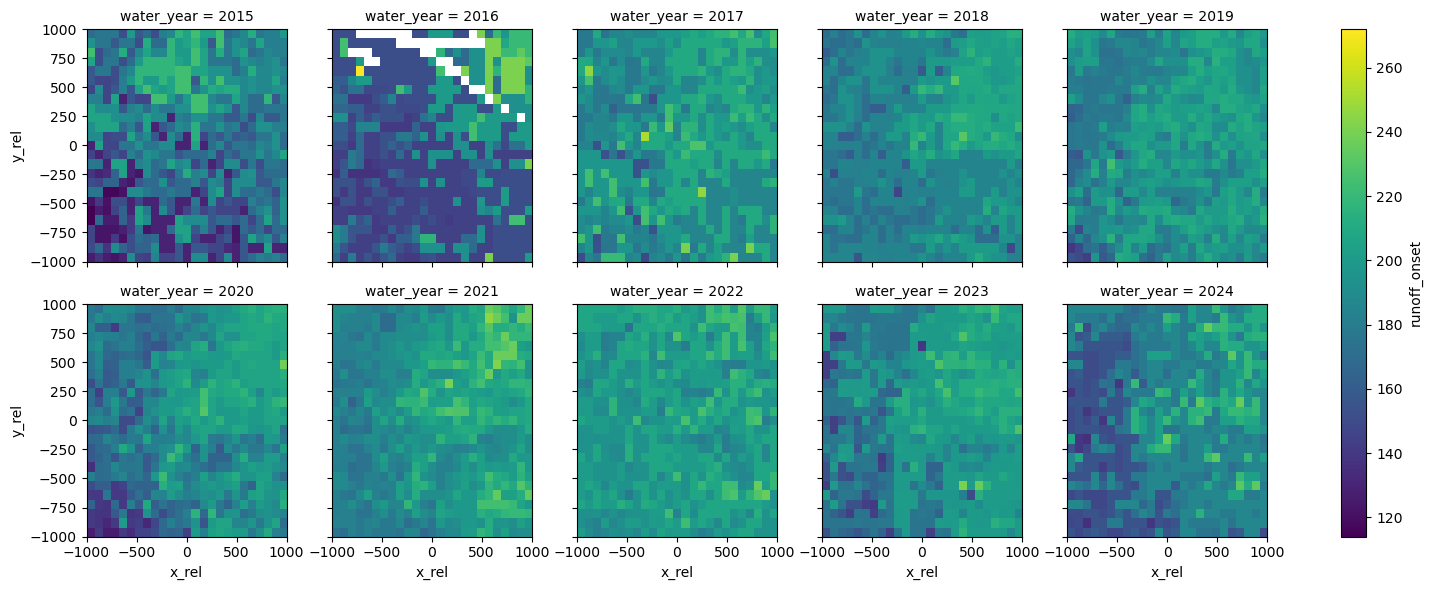

In [24]:
# Verification
chips_ds = xr.open_zarr(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH)
print(chips_ds)

assert np.array_equal(chips_ds.x_rel.values, TARGET_REL), "x_rel mismatch"
assert np.array_equal(chips_ds.y_rel.values, TARGET_REL), "y_rel mismatch"
print(f"\nx_rel/y_rel identical across all stations ✓  ({len(TARGET_REL)} values: {TARGET_REL[0]}…{TARGET_REL[-1]} m)")

chips_ds['runoff_onset'].sel(station_id='679_WA_SNTL').plot.imshow(col='water_year', col_wrap=5)

## Combine chip Zarr and SWE timing Zarr

After both Zarrs are complete, merge them in memory (or write a combined Zarr).
`max_swe_timing_ds` has dims `(station_id, water_year)` and shares the `station_id` dimension with the chip dataset, so `xr.merge` aligns on both.

In [25]:
runoff_onset_chips_ds = xr.open_zarr(RUNOFF_ONSET_STATION_CHIPS_OUTPUT_ZARR_FILEPATH)
runoff_onset_chips_ds

<xarray.Dataset> Size: 79MB
Dimensions:              (station_id: 1210, y_rel: 25, x_rel: 25, water_year: 10)
Coordinates:
  * station_id           (station_id) <U13 63kB '1006_NV_SNTL' ... 'WC3'
    band                 (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg     (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y        (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                 (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
  * y_rel                (y_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * x_rel                (x_rel) int64 200B -960 -880 -800 -720 ... 800 880 960
  * water_year           (water_year) int64 80B 2015 2016 2017 ... 2023 2024
Data variables:
    dem                  (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    fcf                  (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    runoff_onset         (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    snow_class           (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    temporal_resolution  (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    worldcover           (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    x_abs                (station_id, x_rel) float64 242kB dask.array<chunksize=(30, 25), meta=np.ndarray>
    y_abs                (station_id, y_rel) float64 242kB dask.array<chunksize=(30, 25), meta=np.ndarray>

In [26]:
max_swe_timing_ds = xr.open_zarr(MAX_SWE_TIMING_OUTPUT_ZARR_FILEPATH)
max_swe_timing_ds

<xarray.Dataset> Size: 871kB
Dimensions:                   (water_year: 10, station_id: 1210)
Coordinates:
  * water_year                (water_year) int64 80B 2015 2016 ... 2023 2024
  * station_id                (station_id) <U16 77kB '1000_OR_SNTL' ... 'WWC_...
    client                    (station_id) <U6 29kB dask.array<chunksize=(1210,), meta=np.ndarray>
    elevation                 (station_id) float32 5kB dask.array<chunksize=(1210,), meta=np.ndarray>
    latitude                  (station_id) float64 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    longitude                 (station_id) float64 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    network                   (station_id) <U5 24kB dask.array<chunksize=(1210,), meta=np.ndarray>
    state                     (station_id) <U2 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    station_name              (station_id) <U36 174kB dask.array<chunksize=(1210,), meta=np.ndarray>
Data variables:
    100pct_of_max_SWE_timing  (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    50pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    90pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    95pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    99pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    max_SWE_value             (water_year, station_id) float32 48kB dask.array<chunksize=(10, 1210), meta=np.ndarray>

In [ ]:
snow_pillow_chips_and_max_swe_timing_ds = xr.merge([runoff_onset_chips_ds, max_swe_timing_ds], join='inner')
snow_pillow_chips_and_max_swe_timing_ds

<xarray.Dataset> Size: 80MB
Dimensions:                   (station_id: 1210, water_year: 10, x_rel: 25,
                               y_rel: 25)
Coordinates: (12/16)
  * station_id                (station_id) <U16 77kB '1006_NV_SNTL' ... 'WC3'
    band                      (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_epsg          (station_id) int64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_x             (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    station_utm_y             (station_id) float64 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    time                      (station_id) datetime64[ns] 10kB dask.array<chunksize=(30,), meta=np.ndarray>
    ...                        ...
    network                   (station_id) <U5 24kB dask.array<chunksize=(1210,), meta=np.ndarray>
    state                     (station_id) <U2 10kB dask.array<chunksize=(1210,), meta=np.ndarray>
    station_name              (station_id) <U36 174kB dask.array<chunksize=(1210,), meta=np.ndarray>
  * water_year                (water_year) int64 80B 2015 2016 ... 2023 2024
  * x_rel                     (x_rel) int64 200B -960 -880 -800 ... 800 880 960
  * y_rel                     (y_rel) int64 200B -960 -880 -800 ... 800 880 960
Data variables: (12/14)
    dem                       (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    fcf                       (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    runoff_onset              (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    snow_class                (station_id, y_rel, x_rel) float64 6MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    temporal_resolution       (station_id, water_year, y_rel, x_rel) float32 30MB dask.array<chunksize=(30, 10, 25, 25), meta=np.ndarray>
    worldcover                (station_id, y_rel, x_rel) float32 3MB dask.array<chunksize=(30, 25, 25), meta=np.ndarray>
    ...                        ...
    100pct_of_max_SWE_timing  (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    50pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    90pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    95pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    99pct_of_max_SWE_timing   (water_year, station_id) float64 97kB dask.array<chunksize=(10, 1210), meta=np.ndarray>
    max_SWE_value             (water_year, station_id) float32 48kB dask.array<chunksize=(10, 1210), meta=np.ndarray>

: 